# GNSS Example

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pymap3d as pm
from gnss_scintillation import parse, analyze, utils

In [27]:
filename = '170111_070000.nvd.gz'
gnssdata = parse.ParseNovatel(filename)

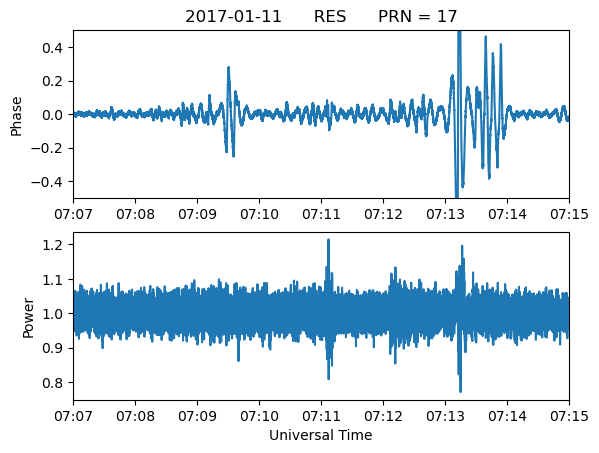

In [32]:
time = utils.gps2utc(np.array(gnssdata.tstmp_wnc), np.array(gnssdata.tstmp_tow))
dt_phs = analyze.phase_detrend(gnssdata.phase[17])
dt_pwr = analyze.power_detrend(gnssdata.power[17])

fig = plt.figure()
ax = fig.add_subplot(211)
ax.plot(time, dt_phs)
ax.set_ylim([-0.5,0.5])
ax.set_xlim([np.datetime64('2017-01-11T07:07:00'), np.datetime64('2017-01-11T07:15:00')])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylabel('Phase')
ax.set_title(f'{time[0].astype('datetime64[D]')}      RES      PRN = 17')
ax = fig.add_subplot(212)
ax.plot(time, dt_pwr)
ax.set_xlim([np.datetime64('2017-01-11T07:07:00'), np.datetime64('2017-01-11T07:15:00')])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Universal Time')
ax.set_ylabel('Power')

plt.savefig('gnss_example.png')